In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, Birch
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_wine
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
from sklearn.cluster import SpectralClustering, AffinityPropagation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, Birch, SpectralClustering, AffinityPropagation, OPTICS
from sklearn.mixture import GaussianMixture
from hdbscan import HDBSCAN
from sklearn.ensemble import IsolationForest
from minisom import MiniSom
from sklearn.model_selection import ParameterGrid
from sklearn.base import clone
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
from deap import base, creator, tools, algorithms

with warnings.catch_warnings():
    warnings.simplefilter("ignore")



In [2]:
# Load data
df_base = pd.read_csv('./cicids_20417_profiles_new.csv', header=0)
all_ips = df_base.iloc[:, 31]
#print("ISX 2014 Profile Count:", len(all_ips))
#print("ISX 2014 Raw Log Count: 14,502,784")
print("CIC-IDS 2017 Profile Count:", len(all_ips))
print("CIC-IDS 2017 Raw Log Count: 55,066,444")
kmeans_cluster_count = 3
df_base.isnull().values.any()
df_base.fillna(0, inplace=True)

cols = ["P1_rph","P2_unique_dns_req", "P3_domain_rph", "P4_avg_rpm", "P5_high_req", "P6_mx", "P7_ptr", "P8_dnsserver", "P9_TDL", "P10_SDL",
        "P11_unique_ratio", "P12_nx", "P13_flow_ratio", "P14_dnsrph", "P15_len", "P16_IRC_ratio", "P17_domain_length",
        "P18_SMB_ratio", "P19_TLS_ratio", "P20_SSH_ratio", "P21_MQTT_ratio", "P22_TFTP_ratio", "P23_NBNS_ratio",
        "P24_TCP_ratio", "P25_DCERPC_ratio", "P26_ICMP_ratio", "P27_DHCP_ratio", "P28_UNIQUEDST_count", "P29_DST_count"]
my_data = df_base.drop(["ReqTime", "ip_src", "RowNo"], axis=1)
cluster_count=3

CIC-IDS 2017 Profile Count: 18592
CIC-IDS 2017 Raw Log Count: 55,066,444


In [3]:
all_ips=list(set(df_base["ip_src"]))
infected_ips = [#"205.174.165.73",
#"205.174.165.69",
#"205.174.165.70",
#"205.174.165.71",
"192.168.10.50",
"205.174.165.68",
"192.168.10.51",
"205.174.165.66",
"192.168.10.19",
"192.168.10.17",
"192.168.10.16",
"192.168.10.12",
"192.168.10.9",
"192.168.10.5",
"192.168.10.8",
"192.168.10.14",
"192.168.10.15",
"192.168.10.25"]
infected_ips = [itm for itm in infected_ips if itm in all_ips]
print("infected_ips:")
print(len(infected_ips))


infected_ips:
12


In [4]:
my_data.describe()

,P1_rph,P2_unique_dns_req,P3_domain_rph,P4_avg_rpm,P5_high_req,P6_mx,P7_ptr,P8_dnsserver,P9_TDL,P10_SDL,...,P20_SSH_ratio,P21_MQTT_ratio,P22_TFTP_ratio,P23_NBNS_ratio,P24_TCP_ratio,P25_DCERPC_ratio,P26_ICMP_ratio,P27_DHCP_ratio,P28_UNIQUEDST_count,P29_DST_count
count,1.859200e+04,18592.000000,18592.000000,18592.000000,18592.000000,18592.000000,18592.000000,18592.000000,18592.0,18592.000000,...,18592.000000,18592.0,18592.0,18592.000000,18592.000000,18592.000000,18592.000000,18592.0,18592.000000,1.859200e+04
mean,2.826037e+03,12.000753,0.725904,2.218320,0.344342,0.194385,8.217943,0.000108,0.0,14.208531,...,0.000974,0.0,0.0,0.000448,0.534390,0.000015,0.000015,0.0,8.416254,2.462853e+03
std,4.405023e+04,130.266167,8.873610,30.089668,6.734072,10.091202,154.960428,0.010371,0.0,143.193263,...,0.010963,0.0,0.0,0.007236,0.310443,0.000312,0.000312,0.0,48.895574,3.919118e+04
min,1.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000e+00
25%,1.490000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.379944,0.000000,0.000000,0.0,1.000000,1.200000e+02
50%,2.590000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.615659,0.000000,0.000000,0.0,1.000000,2.110000e+02
75%,5.980000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.772727,0.000000,0.000000,0.0,3.000000,5.050000e+02
max,2.611693e+06,4449.000000,482.000000,1082.000000,596.000000,838.000000,8918.000000,1.000000,0.0,4449.000000,...,0.725279,0.0,0.0,0.304225,1.000000,0.020408,0.020408,0.0,977.000000,2.611693e+06


In [5]:

# Inspect the dataframe
print(df_base.columns)
print(df_base.head())


Index(['RowNo', 'P1_rph', 'P2_unique_dns_req', 'P3_domain_rph', 'P4_avg_rpm',
       'P5_high_req', 'P6_mx', 'P7_ptr', 'P8_dnsserver', 'P9_TDL', 'P10_SDL',
       'P11_unique_ratio', 'P12_nx', 'P13_flow_ratio', 'P14_dnsrph', 'P15_len',
       'P16_IRC_ratio', 'P17_domain_length', 'P18_SMB_ratio', 'P19_TLS_ratio',
       'P20_SSH_ratio', 'P21_MQTT_ratio', 'P22_TFTP_ratio', 'P23_NBNS_ratio',
       'P24_TCP_ratio', 'P25_DCERPC_ratio', 'P26_ICMP_ratio', 'P27_DHCP_ratio',
       'P28_UNIQUEDST_count', 'P29_DST_count', 'ReqTime', 'ip_src'],
      dtype='object')
   RowNo  P1_rph  P2_unique_dns_req  P3_domain_rph  P4_avg_rpm  P5_high_req  \
0      1     524                  0              0           0            0   
1      2     547                  0              0           0            0   
2      3     544                  0              0           0            0   
3      4     433                  0              0           0            0   
4      5    2318                  0      

In [6]:
# Data preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(my_data)
scaled_df = pd.DataFrame(X_scaled, columns=my_data.columns)


In [7]:
my_data.isnull().values.any()

False

In [8]:

my_data.head(2)

,P1_rph,P2_unique_dns_req,P3_domain_rph,P4_avg_rpm,P5_high_req,P6_mx,P7_ptr,P8_dnsserver,P9_TDL,P10_SDL,...,P20_SSH_ratio,P21_MQTT_ratio,P22_TFTP_ratio,P23_NBNS_ratio,P24_TCP_ratio,P25_DCERPC_ratio,P26_ICMP_ratio,P27_DHCP_ratio,P28_UNIQUEDST_count,P29_DST_count
0,524,0,0,0,0,0,0,0,0,0,...,0.0,0,0,0.0,0.0,0.0,0.0,0,0,524
1,547,0,0,0,0,0,0,0,0,0,...,0.0,0,0,0.0,0.0,0.0,0.0,0,0,0


In [9]:
X=scaled_df.values


In [10]:
from sklearn.model_selection import GridSearchCV
pca=PCA(n_components=2)
# تحلیل ناهنجاری با استفاده از PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled) 
reduced_X=pd.DataFrame(data=pca.fit_transform(X),columns=['PCA1','PCA2'])

reduced_X.head()

,PCA1,PCA2
0,-0.328860,-0.157810
1,-0.129497,-0.015869
2,-0.421506,-0.100327
3,-0.421497,-0.098091
4,-0.343151,-0.051812


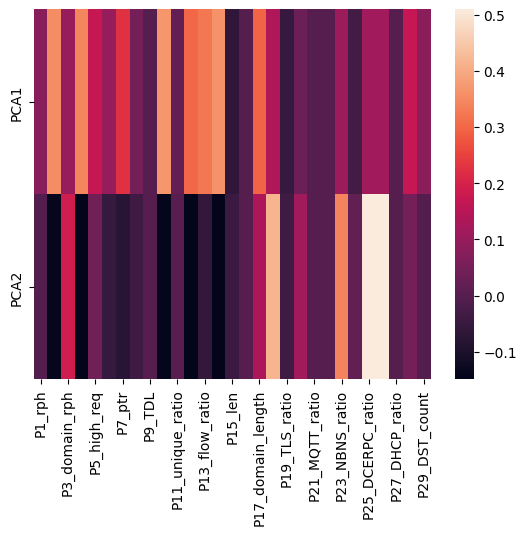

In [11]:
component_df=pd.DataFrame(pca.components_,index=['PCA1',"PCA2"],columns=my_data.columns)
# Heat map
sns.heatmap(component_df)
plt.show()

In [12]:
param_grids = {
    'KMeans': {'n_clusters': [2, 3, 4, 5, 6]},
    'AgglomerativeClustering': {'n_clusters': [2, 3, 4, 5, 6]},
    'DBSCAN': {'eps': [0.3, 0.5, 0.7], 'min_samples': [3, 5, 10]},
    'GaussianMixture': {'n_components': [2, 3, 4, 5, 6], 'covariance_type': ['full', 'tied', 'diag', 'spherical']},
    'Birch': {'n_clusters': [2, 3, 4, 5, 6]},
    'MeanShift': {'bandwidth': [1, 2, 3]},
    'SpectralClustering': {'n_clusters': [2, 3, 4, 5, 6], 'affinity': ['nearest_neighbors', 'rbf']}, #graph
    'AffinityPropagation': {'damping': [0.5, 0.6, 0.7, 0.8, 0.9]}, #graph
    'HDBSCAN': {'min_cluster_size': [5, 10, 15]},
    'OPTICS': {'min_samples': [5, 10, 15], 'xi': [0.01, 0.05, 0.1], 'min_cluster_size': [0.05, 0.1, 0.2]},
}

# Define clustering models
models = {
    'KMeans': KMeans(random_state=0),
    'AgglomerativeClustering': AgglomerativeClustering(),
    'DBSCAN': DBSCAN(),
    'GaussianMixture': GaussianMixture(random_state=0),
    'Birch': Birch(),
    'MeanShift': MeanShift(),
    #'SpectralClustering': SpectralClustering(random_state=0),
  #  'AffinityPropagation': AffinityPropagation(),
    'HDBSCAN': HDBSCAN(),
    'OPTICS': OPTICS(),
}

In [13]:
import ipaddress
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix


def is_private_ip(ip):
    return True
    try:
        ip_obj = ipaddress.ip_address(ip)
        return ip_obj.is_private
    except ValueError:
        return False 

In [14]:
# Calculate ROC AUC for each model
def calculate_roc_auc(model, X, y_true):
  try:
    model.fit(X)
    if hasattr(model, 'labels_'):
        y_pred = model.labels_
    else:
        y_pred = model.predict(X)
    clusters = {}
    n = 0
    for item in y_pred:
        if item in clusters:
            clusters[item].append(df_base.iloc[n]['ip_src'])
        else:
            clusters[item] = [df_base.iloc[n]['ip_src']]
        
        n +=1
    normal_cluster=0
    predicted_labels=[]
    
    for item in clusters:
        if(len(clusters[item])>len(clusters[normal_cluster])):
            normal_cluster=item
        
        # print ("Cluster ", item,' Count: ',len(clusters[item]),' DCCount: ',len(list(set(clusters[item]))))
        # print("Count: ",len(list(set(clusters[item]))))
     #   print("Data: \n",(list(set(clusters[item]))),"\n\n")
        if(item>0):
            for i in clusters[item]:
                 predicted_labels.append(i)
    # print("Normal Cluster index: ",normal_cluster)
    # برچسب‌های خوشه (تخمین زده شده)
    bad_items=[]
    for item in clusters:
        if(item!=normal_cluster):
            for bd_item in list(set(clusters[item])):
                bad_items.append(bd_item)
   # print("Bad IP Count "+str(model)+": " ,len(bad_items))
    white_list=["8.8.8.8","4.2.2.2","172.16.0.1","205.174.165.80","192.168.10.3"]
    
#    for item in bad_items:
    #    if item in white_list:
         #   bad_items.remove(item)
    
   # for item in bad_items:
     #   if is_private_ip(item)==False:
    #        bad_items.remove(item)
    y_true = []
    
    y_scores = []
    FP = []
    FN = []
    TP = []
    TN = []
    
    
    detected_ips = bad_items
    
    
    for ip in all_ips:
      if is_private_ip(ip):
        if ip in infected_ips :
            y_true.append(1)  # آلوده
        else:
            y_true.append(0)  # عادی
    
        
        if ip in detected_ips :
            #print(ip)
            y_scores.append(1)  # آلوده
        else:
            y_scores.append(0)  # عادی
    
        if not(ip in infected_ips) and (ip in detected_ips) :
            FP.append(ip) 
        if (ip in infected_ips) and not(ip in detected_ips)  :
            FN.append(ip) 
            print("not detected:",str(ip))
        if  (ip in infected_ips) and (ip in detected_ips):
            TP.append(ip) 
        if not(ip in infected_ips) and not(ip in detected_ips) :
            TN.append(ip) 
    y_scores=np.array(y_scores)
    y_true=np.array(y_true)
    print("####Model::::",model)
    print("Infected:" ,len(infected_ips))
    print("Detected:" ,len(bad_items))
    print("FP Count:" ,len(FP))
    print("FN Count:" ,len(FN))
    print("TP Count:" ,len(TP))
    print("TN Count:" ,len(TN))
    print("Distinct IP Count:" ,len(all_ips))
    auroc = roc_auc_score(np.array(y_true),np.array( y_scores))
    print("TP Count:" ,len(TP))
    print("FP Count:" ,len(FP))
    print("@@@@AUROC: ", round(auroc,4))
    print("---------------------------------------")
    return auroc, y_scores, y_true,y_pred
  except:
      return 0, 0, 0,0


In [15]:
print("Models Count: ",str(len(models)))

Models Count:  8


not detected: 192.168.10.17
not detected: 192.168.10.12
not detected: 192.168.10.50
not detected: 192.168.10.51
not detected: 192.168.10.19
not detected: 192.168.10.25
not detected: 192.168.10.16
####Model:::: KMeans(n_clusters=2, random_state=0)
Infected: 12
Detected: 7
FP Count: 2
FN Count: 7
TP Count: 5
TN Count: 5588
Distinct IP Count: 5602
TP Count: 5
FP Count: 2
@@@@AUROC:  0.7082
---------------------------------------
####Model:::: KMeans(n_clusters=3, random_state=0)
Infected: 12
Detected: 18
FP Count: 4
FN Count: 0
TP Count: 12
TN Count: 5586
Distinct IP Count: 5602
TP Count: 12
FP Count: 4
@@@@AUROC:  0.9996
---------------------------------------
####Model:::: KMeans(n_clusters=4, random_state=0)
Infected: 12
Detected: 25
FP Count: 4
FN Count: 0
TP Count: 12
TN Count: 5586
Distinct IP Count: 5602
TP Count: 12
FP Count: 4
@@@@AUROC:  0.9996
---------------------------------------
####Model:::: KMeans(n_clusters=5, random_state=0)
Infected: 12
Detected: 34
FP Count: 4
FN Coun

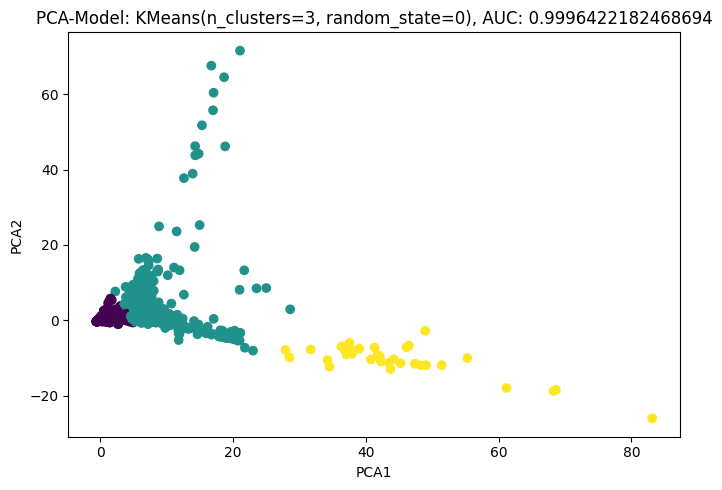

not detected: 192.168.10.8
not detected: 192.168.10.14
not detected: 192.168.10.17
not detected: 192.168.10.12
not detected: 192.168.10.50
not detected: 192.168.10.9
not detected: 192.168.10.51
not detected: 192.168.10.15
not detected: 192.168.10.19
not detected: 192.168.10.25
not detected: 192.168.10.16
not detected: 192.168.10.5
####Model:::: AgglomerativeClustering()
Infected: 12
Detected: 2
FP Count: 2
FN Count: 12
TP Count: 0
TN Count: 5588
Distinct IP Count: 5602
TP Count: 0
FP Count: 2
@@@@AUROC:  0.4998
---------------------------------------
####Model:::: AgglomerativeClustering(n_clusters=3)
Infected: 12
Detected: 20
FP Count: 6
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5602
TP Count: 12
FP Count: 6
@@@@AUROC:  0.9995
---------------------------------------
####Model:::: AgglomerativeClustering(n_clusters=4)
Infected: 12
Detected: 27
FP Count: 6
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5602
TP Count: 12
FP Count: 6
@@@@AUROC:  0.9995
-------

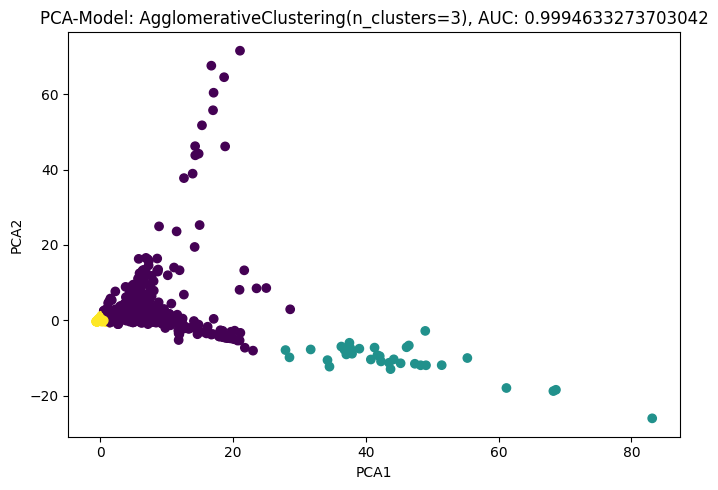

####Model:::: DBSCAN(eps=0.3, min_samples=3)
Infected: 12
Detected: 137
FP Count: 6
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5602
TP Count: 12
FP Count: 6
@@@@AUROC:  0.9995
---------------------------------------
####Model:::: DBSCAN(eps=0.3)
Infected: 12
Detected: 97
FP Count: 6
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5602
TP Count: 12
FP Count: 6
@@@@AUROC:  0.9995
---------------------------------------
####Model:::: DBSCAN(eps=0.3, min_samples=10)
Infected: 12
Detected: 51
FP Count: 6
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5602
TP Count: 12
FP Count: 6
@@@@AUROC:  0.9995
---------------------------------------
####Model:::: DBSCAN(min_samples=3)
Infected: 12
Detected: 97
FP Count: 6
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5602
TP Count: 12
FP Count: 6
@@@@AUROC:  0.9995
---------------------------------------
####Model:::: DBSCAN()
Infected: 12
Detected: 72
FP Count: 6
FN Count: 0
TP Count: 12
TN Count: 55

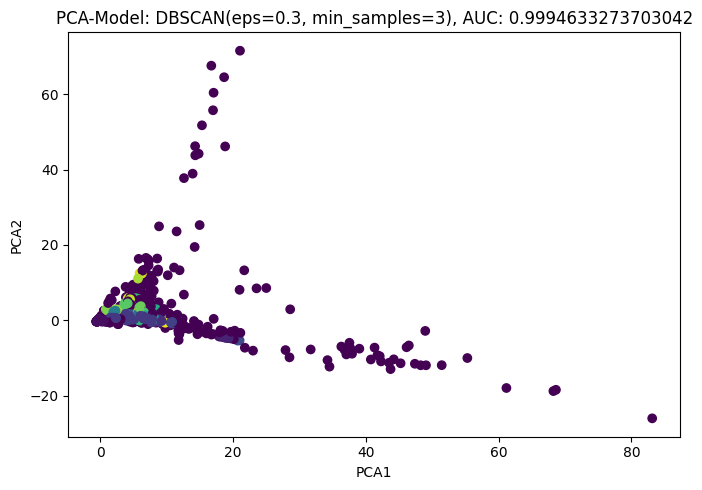

####Model:::: GaussianMixture(n_components=2, random_state=0)
Infected: 12
Detected: 70
FP Count: 58
FN Count: 0
TP Count: 12
TN Count: 5532
Distinct IP Count: 5602
TP Count: 12
FP Count: 58
@@@@AUROC:  0.9948
---------------------------------------
####Model:::: GaussianMixture(n_components=3, random_state=0)
Infected: 12
Detected: 81
FP Count: 58
FN Count: 0
TP Count: 12
TN Count: 5532
Distinct IP Count: 5602
TP Count: 12
FP Count: 58
@@@@AUROC:  0.9948
---------------------------------------
####Model:::: GaussianMixture(n_components=4, random_state=0)
Infected: 12
Detected: 97
FP Count: 64
FN Count: 0
TP Count: 12
TN Count: 5526
Distinct IP Count: 5602
TP Count: 12
FP Count: 64
@@@@AUROC:  0.9943
---------------------------------------
####Model:::: GaussianMixture(n_components=5, random_state=0)
Infected: 12
Detected: 98
FP Count: 64
FN Count: 0
TP Count: 12
TN Count: 5526
Distinct IP Count: 5602
TP Count: 12
FP Count: 64
@@@@AUROC:  0.9943
---------------------------------------


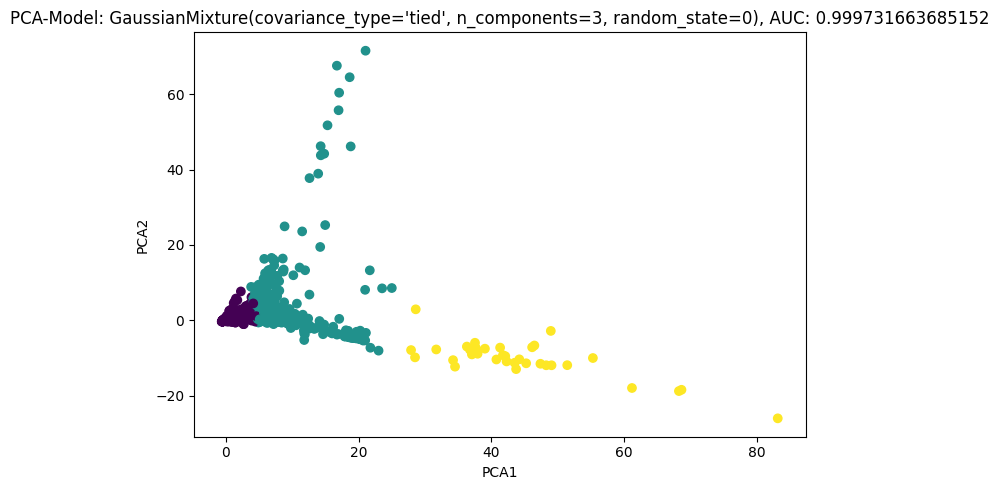

not detected: 192.168.10.8
not detected: 192.168.10.14
not detected: 192.168.10.17
not detected: 192.168.10.12
not detected: 192.168.10.50
not detected: 192.168.10.9
not detected: 192.168.10.51
not detected: 192.168.10.15
not detected: 192.168.10.19
not detected: 192.168.10.25
not detected: 192.168.10.16
not detected: 192.168.10.5
####Model:::: Birch(n_clusters=2)
Infected: 12
Detected: 2
FP Count: 2
FN Count: 12
TP Count: 0
TN Count: 5588
Distinct IP Count: 5602
TP Count: 0
FP Count: 2
@@@@AUROC:  0.4998
---------------------------------------
not detected: 192.168.10.17
not detected: 192.168.10.12
not detected: 192.168.10.50
not detected: 192.168.10.51
not detected: 192.168.10.19
not detected: 192.168.10.16
####Model:::: Birch()
Infected: 12
Detected: 9
FP Count: 2
FN Count: 6
TP Count: 6
TN Count: 5588
Distinct IP Count: 5602
TP Count: 6
FP Count: 2
@@@@AUROC:  0.7498
---------------------------------------
not detected: 192.168.10.17
not detected: 192.168.10.12
not detected: 192.16

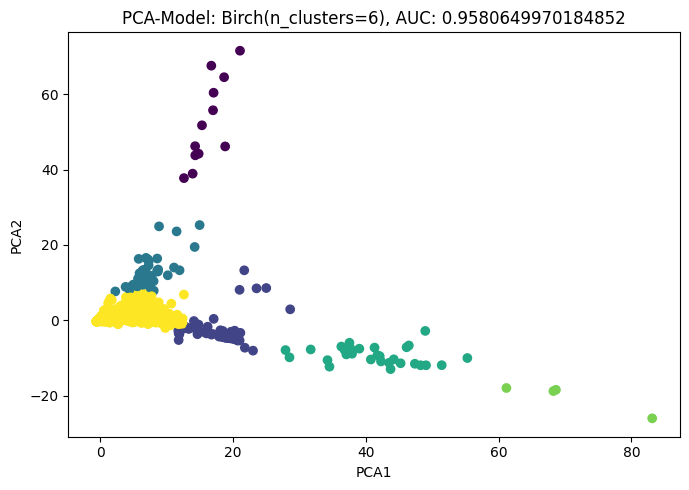

####Model:::: MeanShift(bandwidth=1)
Infected: 12
Detected: 264
FP Count: 6
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5602
TP Count: 12
FP Count: 6
@@@@AUROC:  0.9995
---------------------------------------
####Model:::: MeanShift(bandwidth=2)
Infected: 12
Detected: 123
FP Count: 6
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5602
TP Count: 12
FP Count: 6
@@@@AUROC:  0.9995
---------------------------------------
####Model:::: MeanShift(bandwidth=3)
Infected: 12
Detected: 77
FP Count: 4
FN Count: 0
TP Count: 12
TN Count: 5586
Distinct IP Count: 5602
TP Count: 12
FP Count: 4
@@@@AUROC:  0.9996
---------------------------------------
MeanShift Best Params: {'bandwidth': 3} AUROC: 0.9996422182468694


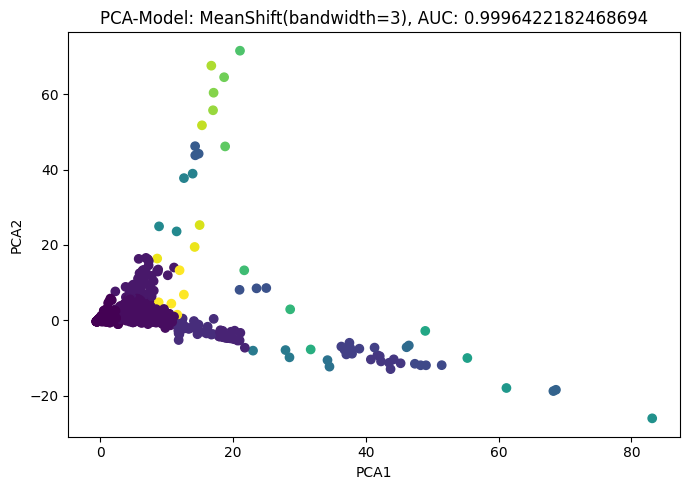

####Model:::: HDBSCAN()
Infected: 12
Detected: 9631
FP Count: 4134
FN Count: 0
TP Count: 12
TN Count: 1456
Distinct IP Count: 5602
TP Count: 12
FP Count: 4134
@@@@AUROC:  0.6302
---------------------------------------
####Model:::: HDBSCAN(min_cluster_size=10)
Infected: 12
Detected: 3761
FP Count: 2509
FN Count: 0
TP Count: 12
TN Count: 3081
Distinct IP Count: 5602
TP Count: 12
FP Count: 2509
@@@@AUROC:  0.7756
---------------------------------------
####Model:::: HDBSCAN(min_cluster_size=15)
Infected: 12
Detected: 3520
FP Count: 2365
FN Count: 0
TP Count: 12
TN Count: 3225
Distinct IP Count: 5602
TP Count: 12
FP Count: 2365
@@@@AUROC:  0.7885
---------------------------------------
HDBSCAN Best Params: {'min_cluster_size': 15} AUROC: 0.7884615384615384


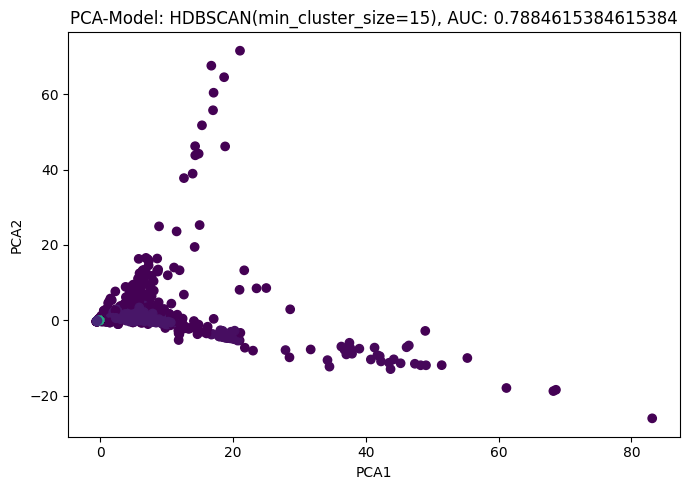

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_optics.py:1083: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


not detected: 192.168.10.8
not detected: 192.168.10.14
not detected: 192.168.10.17
not detected: 192.168.10.12
not detected: 192.168.10.50
not detected: 192.168.10.9
not detected: 192.168.10.51
not detected: 192.168.10.15
not detected: 192.168.10.19
not detected: 192.168.10.25
not detected: 192.168.10.16
not detected: 192.168.10.5
####Model:::: OPTICS(min_cluster_size=0.05, xi=0.01)
Infected: 12
Detected: 1653
FP Count: 1489
FN Count: 12
TP Count: 0
TN Count: 4101
Distinct IP Count: 5602
TP Count: 0
FP Count: 1489
@@@@AUROC:  0.3668
---------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_optics.py:1083: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


not detected: 192.168.10.8
not detected: 192.168.10.14
not detected: 192.168.10.17
not detected: 192.168.10.12
not detected: 192.168.10.50
not detected: 192.168.10.9
not detected: 192.168.10.51
not detected: 192.168.10.15
not detected: 192.168.10.19
not detected: 192.168.10.25
not detected: 192.168.10.16
not detected: 192.168.10.5
####Model:::: OPTICS(min_cluster_size=0.05)
Infected: 12
Detected: 1086
FP Count: 1086
FN Count: 12
TP Count: 0
TN Count: 4504
Distinct IP Count: 5602
TP Count: 0
FP Count: 1086
@@@@AUROC:  0.4029
---------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_optics.py:1083: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


...

####Model:::: OPTICS(min_cluster_size=0.2, min_samples=15, xi=0.01)
Infected: 12
Detected: 2419
FP Count: 2407
FN Count: 0
TP Count: 12
TN Count: 3183
Distinct IP Count: 5602
TP Count: 12
FP Count: 2407
@@@@AUROC:  0.7847
---------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_optics.py:1083: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


####Model:::: OPTICS(min_cluster_size=0.2, min_samples=15)
Infected: 12
Detected: 60
FP Count: 48
FN Count: 0
TP Count: 12
TN Count: 5542
Distinct IP Count: 5602
TP Count: 12
FP Count: 48
@@@@AUROC:  0.9957
---------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_optics.py:1083: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


####Model:::: OPTICS(min_cluster_size=0.2, min_samples=15, xi=0.1)
Infected: 12
Detected: 60
FP Count: 48
FN Count: 0
TP Count: 12
TN Count: 5542
Distinct IP Count: 5602
TP Count: 12
FP Count: 48
@@@@AUROC:  0.9957
---------------------------------------
OPTICS Best Params: {'min_cluster_size': 0.2, 'min_samples': 5, 'xi': 0.1} AUROC: 0.9974955277280858


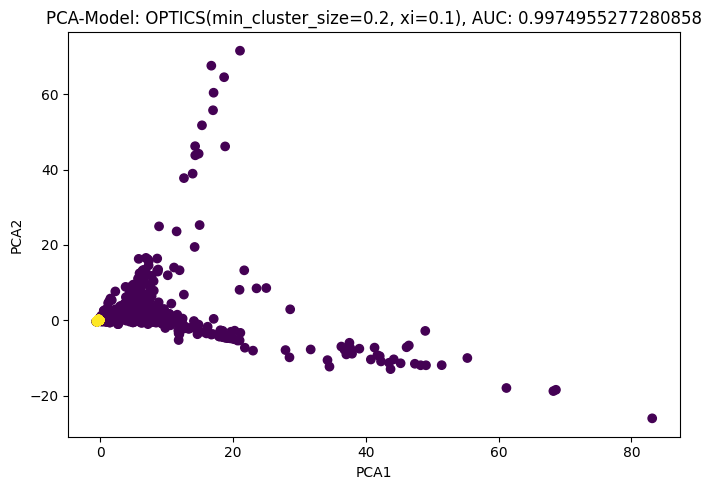

In [16]:
# With  PCA
roc_auc_scores = {}
best_models = {}

for name, model in models.items():

    best_auc = 0
    best_model = None
    best_params = None
    best_y_pred = None
    
    for params in ParameterGrid(param_grids[name]):
        model.set_params(**params)
        try:
            auroc, y_scores, y_true,y_pred = calculate_roc_auc(model, X_pca, df_base[cols])
        except:
            print("Error on "+str(model))
            
        
        if auroc > best_auc:
            best_auc = auroc
            best_model = clone(model)
            best_params = params
            best_y_pred = y_pred
            best_y_true = y_true
            best_y_scores= y_scores
    
    best_models[name] = {"model":best_model,
                         "auroc":best_auc,
                         "params":best_params,
                         "y_pred":best_y_pred,
                         "y_true":best_y_true,
                         "scores":best_y_scores
                        }
    roc_auc_scores[name] = best_auc
   
    print(f"{name} Best Params: {best_params} AUROC: {best_auc}")
    plt.figure(figsize=(7,5))
 
    # Scatter plot
    plt.scatter(reduced_X['PCA1'],reduced_X['PCA2'],c=best_y_pred)
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.title("PCA-Model: "+str(best_model)+", AUC: "+str(best_auc))
    plt.tight_layout()
    plt.show()

In [17]:
roc_auc_table = pd.DataFrame.from_dict(roc_auc_scores, orient='index', columns=['ROC AUC'])
print(roc_auc_table)

                          ROC AUC
KMeans                   0.999642
AgglomerativeClustering  0.999463
DBSCAN                   0.999463
GaussianMixture          0.999732
Birch                    0.958065
MeanShift                0.999642
HDBSCAN                  0.788462
OPTICS                   0.997496


In [18]:
#OLD
# roc_auc_scores = {}
# for name, model in models.items():
#     # auroc, y_scores, y_true = calculate_roc_auc(model, scaled_df, df_base[cols])
#     auroc, y_scores, y_true = calculate_roc_auc(model, X_pca, df_base[cols])
#     roc_auc_scores[name] = auroc
#     print(f"{name} AUROC: {auroc}")

# roc_auc_table = pd.DataFrame.from_dict(roc_auc_scores, orient='index', columns=['ROC AUC'])
# print(roc_auc_table)


In [19]:

# Plot ROC curve and confusion matrix for the best model
best_model_name = roc_auc_table['ROC AUC'].idxmax()
best_model = models[best_model_name]

print("Best Model is:",str(best_model))

Best Model is: GaussianMixture(covariance_type='spherical', n_components=6, random_state=0)


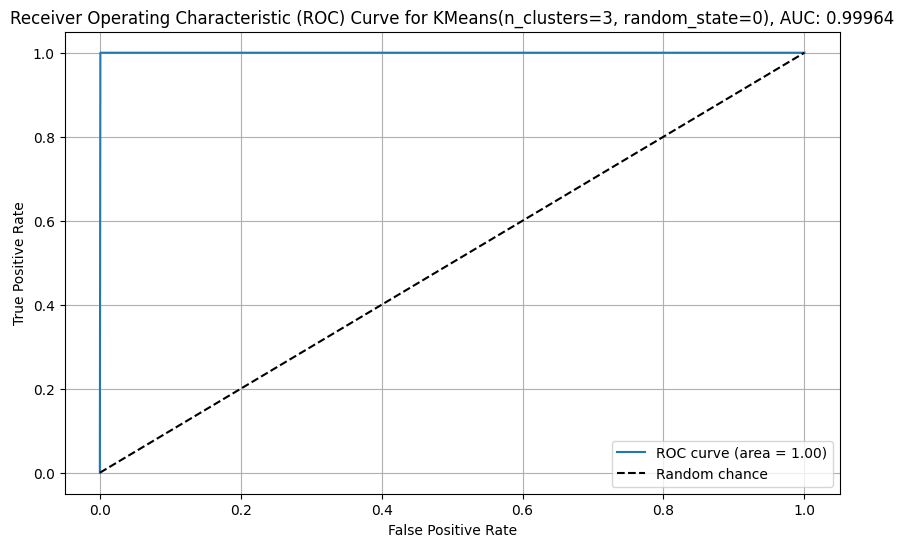

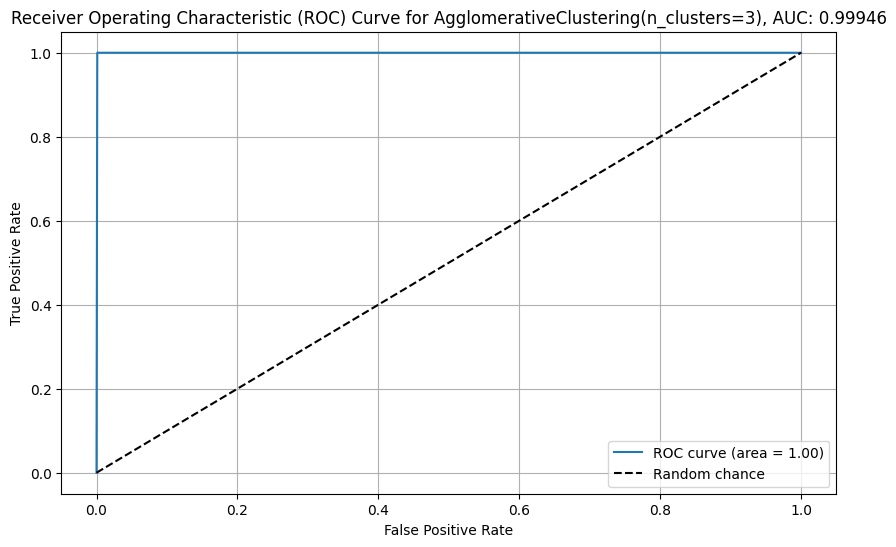

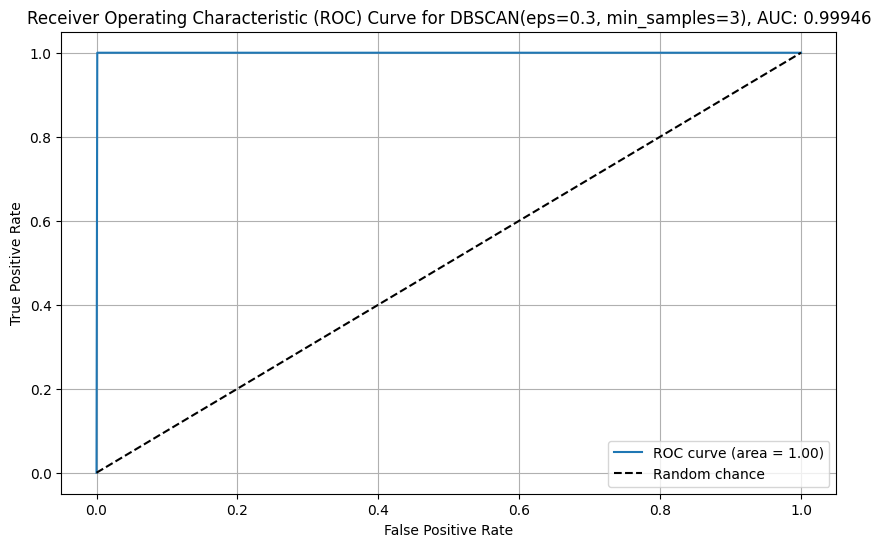

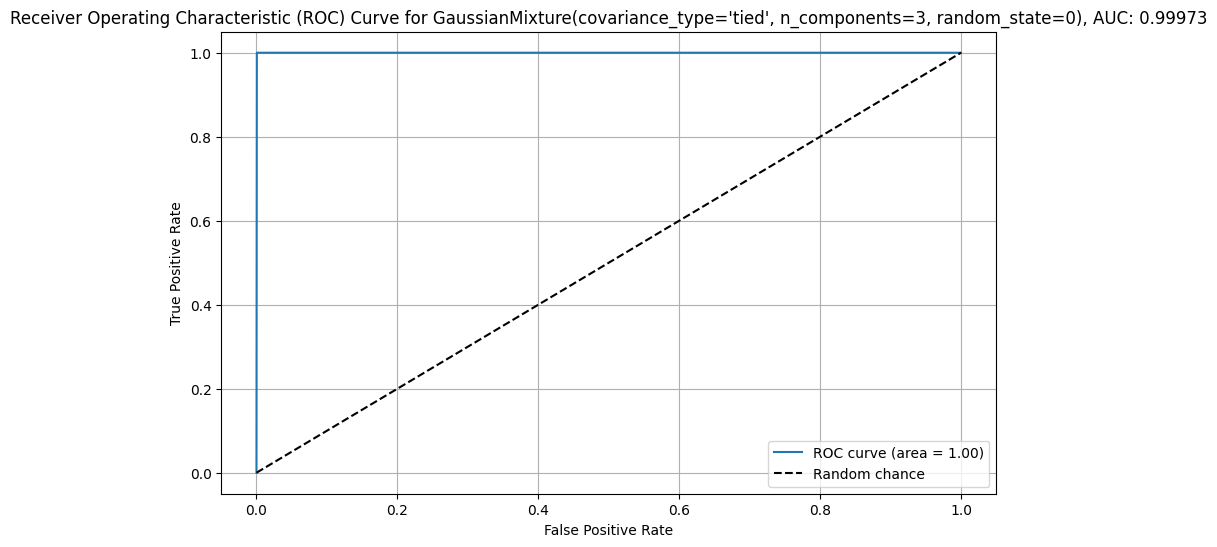

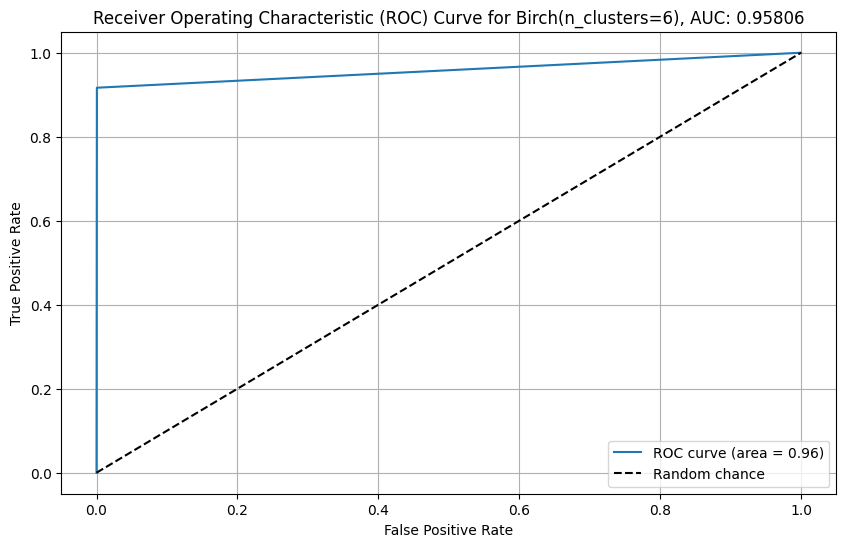

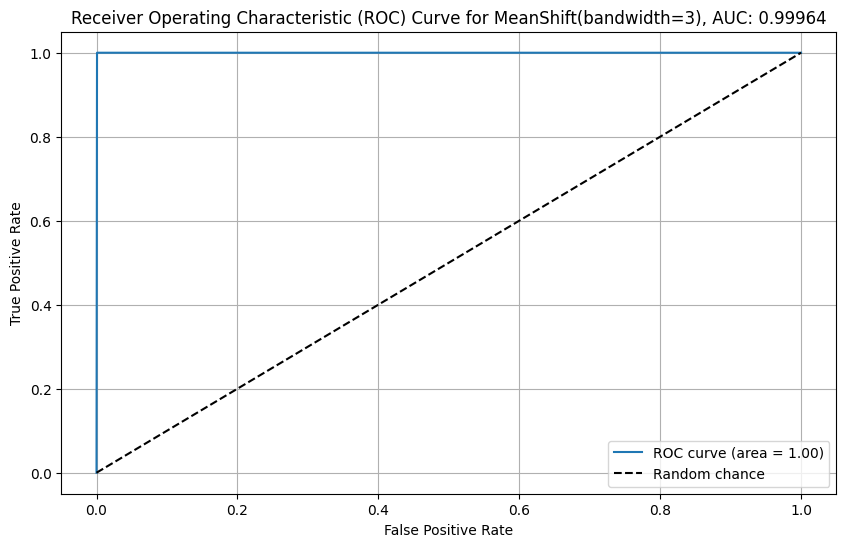

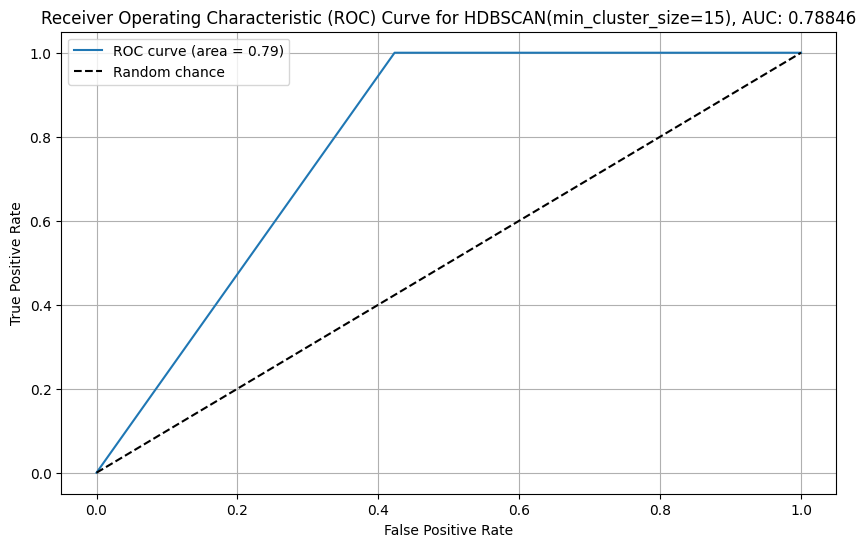

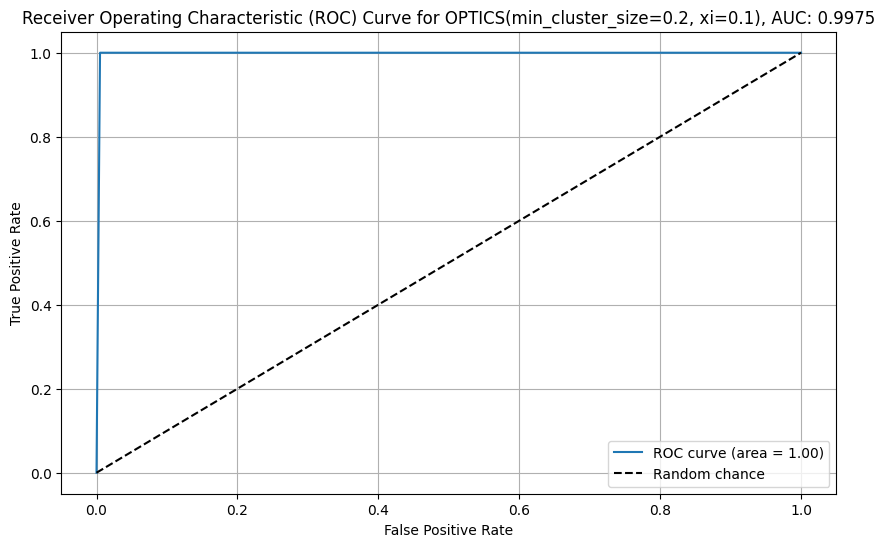

In [20]:
# Receiver Operating Characteristic (ROC) Curve
for name in best_models:
    val=best_models[name]
    model=val['model']
    y_scores=val['scores']
    y_pred=val['y_pred']
    y_true=val['y_true']
    auroc=val['auroc']
    #auroc, y_scores, y_true,y_pred = calculate_roc_auc(model, X_pca, df_base[cols])
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {auroc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve for '+str(model)+", AUC: "+str(round(auroc,5)))
    plt.legend(loc='best')
    plt.grid()
    plt.show()


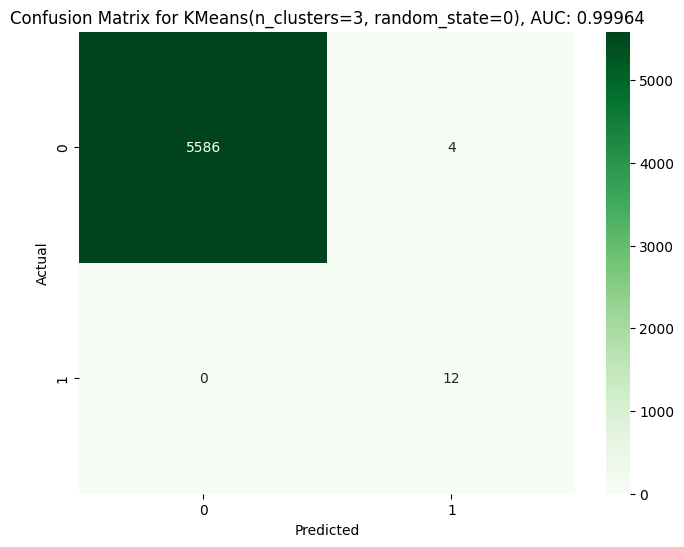

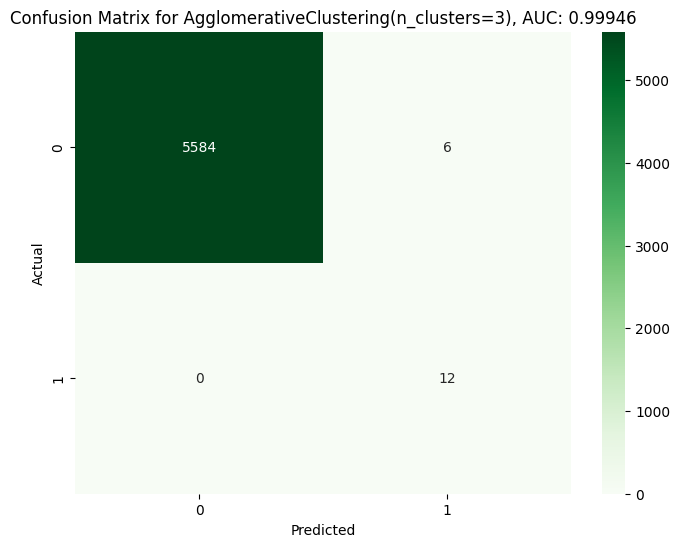

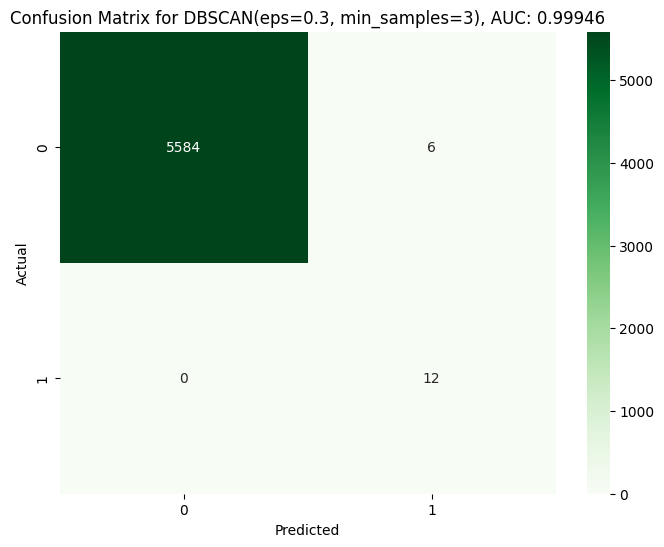

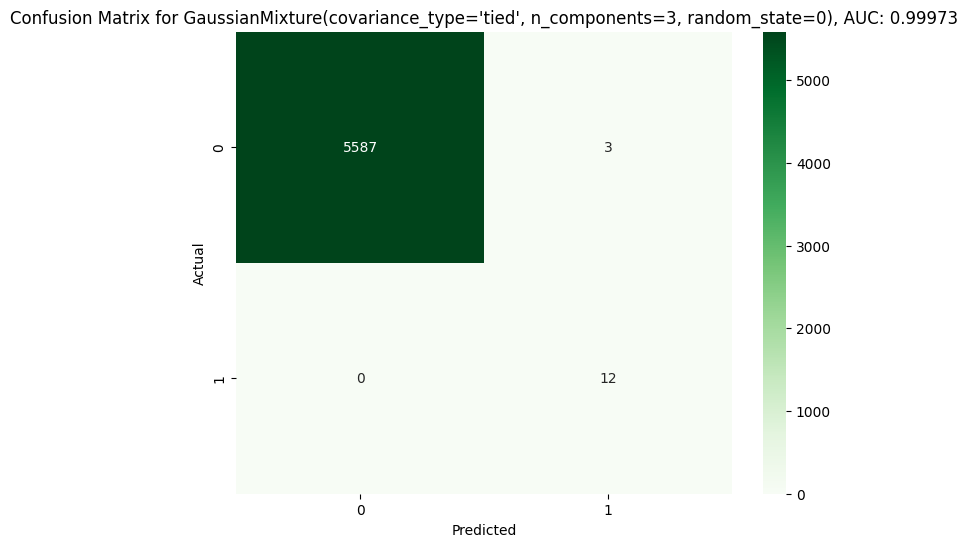

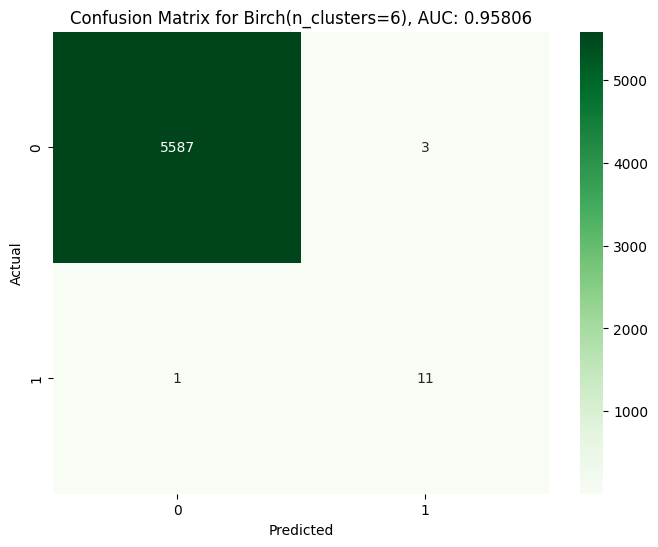

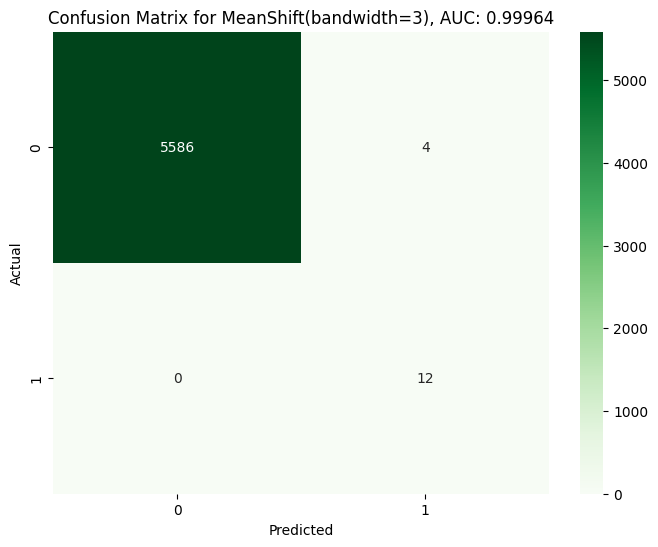

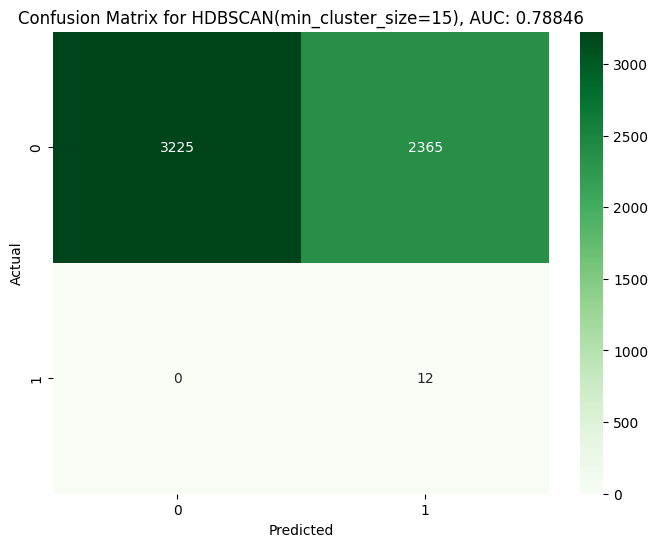

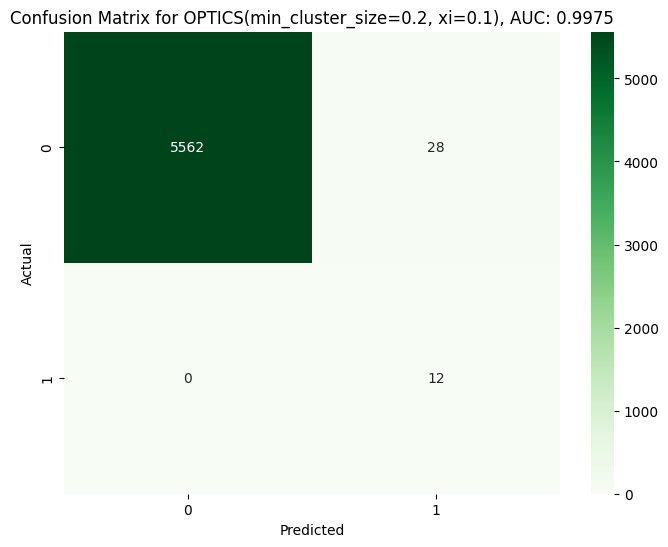

In [21]:

# Plot confusion matrix
for name in best_models:
    val=best_models[name]
    model=val['model']
    y_scores=val['scores']
    y_pred=val['y_pred']
    y_true=val['y_true']
    auroc=val['auroc']
    # Plot ROC Curve
    threshold = 0.5
    y_pred_binary = (y_scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_binary)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix for ' + str(model)+", AUC: "+ str(round(auroc,5)))
    plt.show()
